<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/ECLAT%20Algorithm%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!

Dataset shape:
(333, 10)

Dataset columns:
['name', 'url', 'sku', 'gtin13', 'price', 'currency', 'availability', 'description', 'brand', 'breadcrumbs']

First 5 rows:
                                                name  \
0  Birds Eye Crispy Pancakes Beef & Onion 4 Pack ...   
1                   Unicorn & Dino Storybooks 4 Pack   
2                        Schwartz Fish Seasoning 55G   
3                 Hearty Food Co Mac 'N' Cheese 400G   
4                           Tesco Dijon Mustard 185G   

                                                 url        sku  \
0  https://www.tesco.com/groceries/en-GB/products...  305829059   
1  https://www.tesco.com/groceries/en-GB/products...  311932942   
2  https://www.tesco.com/groceries/en-GB/products...  257522449   
3  https://www.tesco.com/groceries/en-GB/products...  299555755   
4  https://www.tesco.com/groceries/en-GB/products...  260691710   

          gtin13  price currency availability  \
0  50001161252

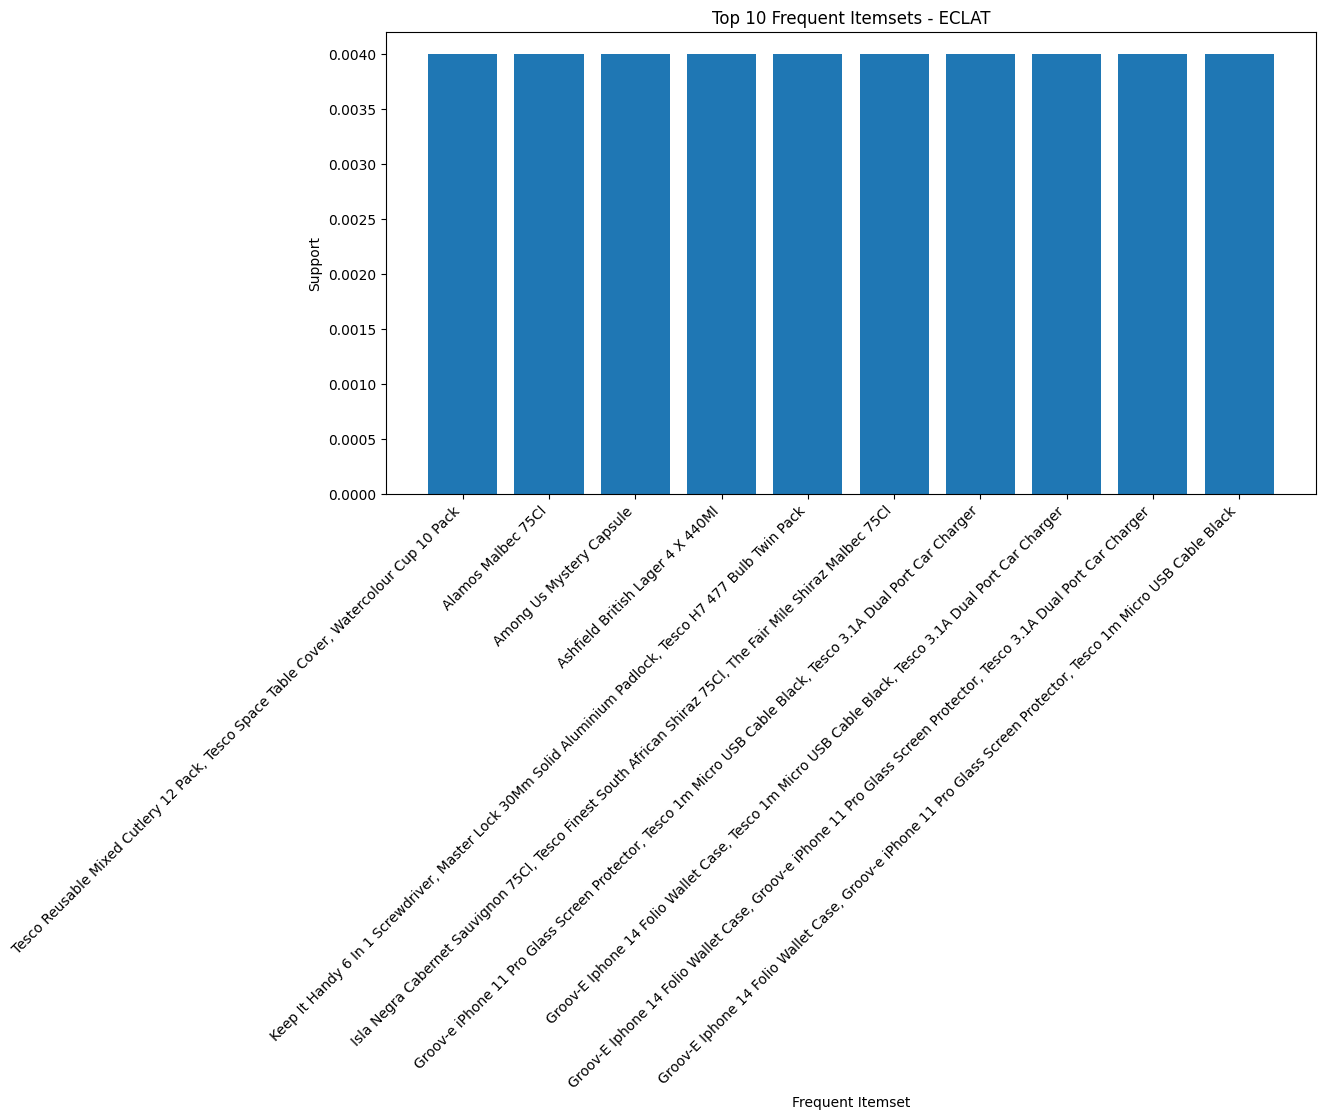

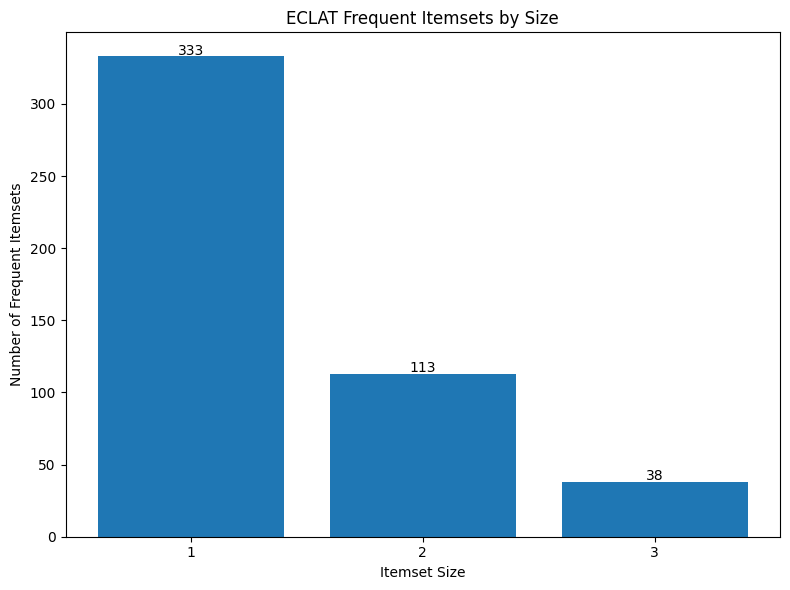

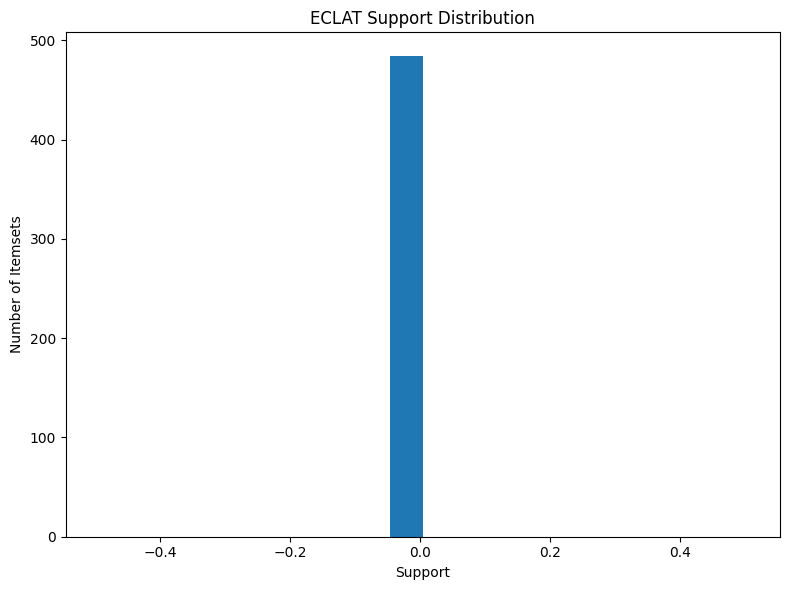



FINAL ECLAT SUMMARY
Total Transactions: 250
Unique Items: 333
Frequent Itemsets: 484
Minimum Support: 0.001
Maximum Support: 0.004

ECLAT execution completed successfully!


In [13]:
# ============================================================
# ECLAT ALGORITHM - GROCERIES DATASET
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/tesco_groceries_dataset-selected-columns.csv")

print("Dataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nDataset columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================
# The original check for 'Member_number', 'Date', and 'itemDescription' is removed
# as these columns are not present in the current dataset. We will adapt
# the transaction creation to the available columns: 'breadcrumbs' and 'name'.


# ============================================================
# 3. REMOVE MISSING VALUES
# ============================================================

# Adapting to available columns: 'breadcrumbs' for transaction grouping, 'name' for items
df = df.dropna(
    subset=[
        "breadcrumbs", # Used as transaction identifier
        "name"         # Used as items in the transaction
    ]
)

print("\nRows after removing missing values:")
print(len(df))


# ============================================================
# 4. CREATE TRANSACTIONS
# ============================================================

# Redefine transactions: group by 'breadcrumbs' (category path) and collect 'name' (product name) as items
transactions = (
    df.groupby(
        ["breadcrumbs"] # Group by category path to define a 'transaction'
    )["name"]         # Collect product names within each category path
    .apply(set)
    .tolist()
)

print("\nNumber of transactions (unique breadcrumbs paths):")
print(len(transactions))


# ============================================================
# 5. REMOVE EMPTY TRANSACTIONS
# ============================================================

transactions = [
    transaction
    for transaction in transactions
    if len(transaction) > 0
]

print(
    "Valid transactions (after removing empty ones):",
    len(transactions)
)


# ============================================================
# 6. CREATE VERTICAL DATABASE
# ============================================================

item_tidsets = {}

for transaction_id, transaction in enumerate(
    transactions
):

    for item in transaction:

        if item not in item_tidsets:

            item_tidsets[item] = set()

        item_tidsets[item].add(
            transaction_id
        )


print(
    "\nTotal unique items:",
    len(item_tidsets)
)


# ============================================================
# 7. SET MINIMUM SUPPORT
# ============================================================

min_support = 0.001 # Lowering min_support to ensure at least some frequent items are found

total_transactions = len(
    transactions
)

min_count = max(
    1,
    int(
        min_support *
        total_transactions
    )
)

print(
    "\nMinimum Support:",
    min_support
)

print(
    "Minimum Transaction Count:",
    min_count
)


# ============================================================
# 8. REMOVE ITEMS BELOW MINIMUM SUPPORT
# ============================================================

item_tidsets = {

    item: tids

    for item, tids in item_tidsets.items()

    if len(tids) >= min_count
}


print(
    "\nFrequent single items:",
    len(item_tidsets)
)


# ============================================================
# 9. ECLAT FUNCTION
# ============================================================

def eclat(
    item_tidsets,
    min_count,
    max_size=3
):

    frequent_itemsets = {}

    items = sorted(
        item_tidsets.keys()
    )

    # --------------------------------------------------------
    # 1-ITEMSETS
    # --------------------------------------------------------

    for item in items:

        tids = item_tidsets[item]

        if len(tids) >= min_count:

            frequent_itemsets[
                (item,)
            ] = tids


    # --------------------------------------------------------
    # 2-ITEMSETS AND 3-ITEMSETS
    # --------------------------------------------------------

    for size in range(
        2,
        max_size + 1
    ):

        print(
            f"Finding {size}-itemsets..."
        )

        for combination in combinations(
            items,
            size
        ):

            tidsets = [

                item_tidsets[item]

                for item in combination

            ]

            common_tids = set.intersection(
                *tidsets
            )

            if len(common_tids) >= min_count:

                frequent_itemsets[
                    combination
                ] = common_tids


    return frequent_itemsets


# ============================================================
# 10. RUN ECLAT
# ============================================================

print("\nRunning ECLAT...")

frequent_itemsets = eclat(
    item_tidsets,
    min_count,
    max_size=3
)

print(
    "\nECLAT completed successfully!"
)


# ============================================================
# 11. CONVERT RESULTS TO DATAFRAME
# ============================================================

results = []

for itemset, tids in frequent_itemsets.items():

    support = (
        len(tids)
        /
        total_transactions
    )

    results.append({

        "Itemset": itemset,

        "Support": support,

        "Count": len(tids),

        "Size": len(itemset)

    })


result_df = pd.DataFrame(
    results
)


# ============================================================
# 12. SORT RESULTS
# ============================================================

result_df = result_df.sort_values(
    by="Support",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 60)

print(
    "ECLAT FREQUENT ITEMSETS"
)

print("=" * 60)

print(
    result_df.head(20).to_string(
        index=False
    )
)


# ============================================================
# 14. DISPLAY TOP 10 ITEMSETS
# ============================================================

print("\n")
print("=" * 60)

print(
    "TOP 10 FREQUENT ITEMSETS"
)

print("=" * 60)

for _, row in result_df.head(10).iterrows():

    items = ", ".join(
        row["Itemset"]
    )

    print(
        f"{items} "
        f"-> Support: "
        f"{row['Support']:.4f} "
        f"-> Count: "
        f"{row['Count']}"
    )


# ============================================================
# 15. GRAPH 1
# TOP 10 FREQUENT ITEMSETS
# ============================================================

top_items = result_df.head(
    10
).copy()

top_items["Item"] = (
    top_items["Itemset"]
    .apply(
        lambda x:
        ", ".join(x)
    )
)


plt.figure(
    figsize=(12, 6)
)

plt.bar(
    top_items["Item"],
    top_items["Support"]
)

plt.xlabel(
    "Frequent Itemset"
)

plt.ylabel(
    "Support"
)

plt.title(
    "Top 10 Frequent Itemsets - ECLAT"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. GRAPH 2
# ITEMSET SIZE DISTRIBUTION
# ============================================================

size_counts = (
    result_df["Size"]
    .value_counts()
    .sort_index()
)


plt.figure(
    figsize=(8, 6)
)

plt.bar(
    size_counts.index.astype(str),
    size_counts.values
)

plt.xlabel(
    "Itemset Size"
)

plt.ylabel(
    "Number of Frequent Itemsets"
)

plt.title(
    "ECLAT Frequent Itemsets by Size"
)

for i, value in enumerate(
    size_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 17. GRAPH 3
# SUPPORT DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.hist(
    result_df["Support"],
    bins=20
)

plt.xlabel(
    "Support"
)

plt.ylabel(
    "Number of Itemsets"
)

plt.title(
    "ECLAT Support Distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)

print(
    "FINAL ECLAT SUMMARY"
)

print("=" * 60)

print(
    "Total Transactions:",
    total_transactions
)

print(
    "Unique Items:",
    len(item_tidsets)
)

print(
    "Frequent Itemsets:",
    len(result_df)
)

print(
    "Minimum Support:",
    min_support
)

print(
    "Maximum Support:",
    round(
        result_df["Support"].max(),
        4
    )
)

print("\nECLAT execution completed successfully!")